# Analyse des données — E-Commerce Sénégal
**Plateforme Data Pipelines DSIA** — Mouhamadou Makhtar DIOUF

Ce notebook analyse les données collectées par la plateforme :
- Statistiques globales sur les paiements
- Répartition Wave vs Orange Money
- Analyse des anomalies détectées
- Évolution des taux de change XOF/USD

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

# Connexion PostgreSQL (depuis Jupyter dans Docker)
conn = psycopg2.connect(
    host='postgres',
    port=5432,
    database='ecommerce_senegal',
    user='dataeng',
    password='senegal2024'
)
print('Connexion PostgreSQL OK')

Connexion PostgreSQL OK


## 1. Statistiques globales

In [2]:
df_global = pd.read_sql("""
    SELECT
        COUNT(*)                                              AS total_transactions,
        ROUND(SUM(montant)::numeric, 2)                       AS montant_total_xof,
        ROUND(AVG(montant)::numeric, 2)                       AS montant_moyen_xof,
        SUM(CASE WHEN statut = 'SUCCESS'      THEN 1 ELSE 0 END) AS nb_success,
        SUM(CASE WHEN statut = 'FAILED'       THEN 1 ELSE 0 END) AS nb_echecs,
        SUM(CASE WHEN methode_paiement = 'WAVE' THEN 1 ELSE 0 END) AS nb_wave,
        SUM(CASE WHEN methode_paiement = 'ORANGE_MONEY' THEN 1 ELSE 0 END) AS nb_orange
    FROM paiements
""", conn)

print('=== STATISTIQUES GLOBALES ===')
df_global.T

=== STATISTIQUES GLOBALES ===


/tmp/ipykernel_6015/227051729.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_global = pd.read_sql("""


,0
total_transactions,1.146000e+03
montant_total_xof,3.810851e+08
montant_moyen_xof,3.325350e+05
nb_success,1.017000e+03
nb_echecs,6.600000e+01
nb_wave,5.790000e+02
nb_orange,5.670000e+02


## 2. Répartition Wave vs Orange Money

/tmp/ipykernel_6015/2458292220.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_methodes = pd.read_sql("""


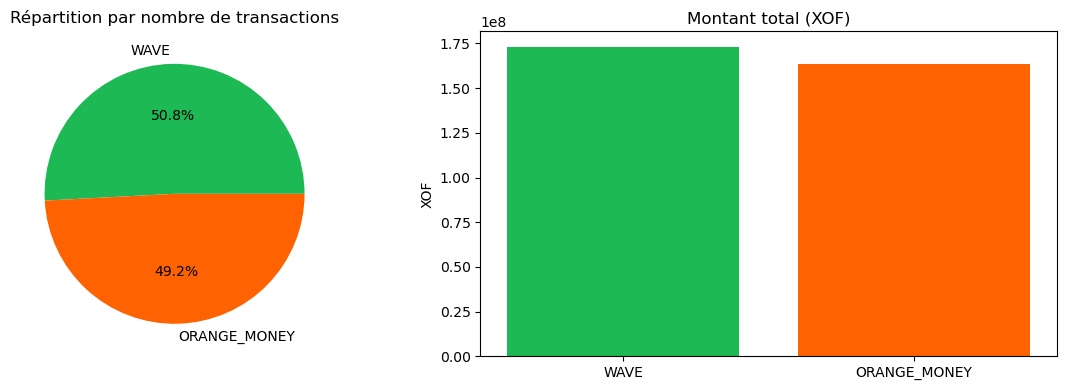

,methode_paiement,nb_transactions,montant_total
0,WAVE,517,1.731461e+08
1,ORANGE_MONEY,500,1.637760e+08


In [3]:
df_methodes = pd.read_sql("""
    SELECT methode_paiement,
           COUNT(*) AS nb_transactions,
           ROUND(SUM(montant)::numeric, 2) AS montant_total
    FROM paiements
    WHERE statut = 'SUCCESS'
    GROUP BY methode_paiement
    ORDER BY nb_transactions DESC
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    df_methodes['nb_transactions'],
    labels=df_methodes['methode_paiement'],
    autopct='%1.1f%%',
    colors=['#1DB954', '#FF6200']
)
axes[0].set_title('Répartition par nombre de transactions')

axes[1].bar(
    df_methodes['methode_paiement'],
    df_methodes['montant_total'],
    color=['#1DB954', '#FF6200']
)
axes[1].set_title('Montant total (XOF)')
axes[1].set_ylabel('XOF')

plt.tight_layout()
plt.show()
df_methodes

## 3. Analyse des anomalies (topic dédié : anomalies-paiements)

/tmp/ipykernel_6015/3142939730.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ano_type = pd.read_sql("""


=== ANOMALIES PAR TYPE ET SEVERITE ===
      type_anomalie severite  nb
ECHEC_MONTANT_ELEVE   MEDIUM  40
    MONTANT_SUSPECT     HIGH  38


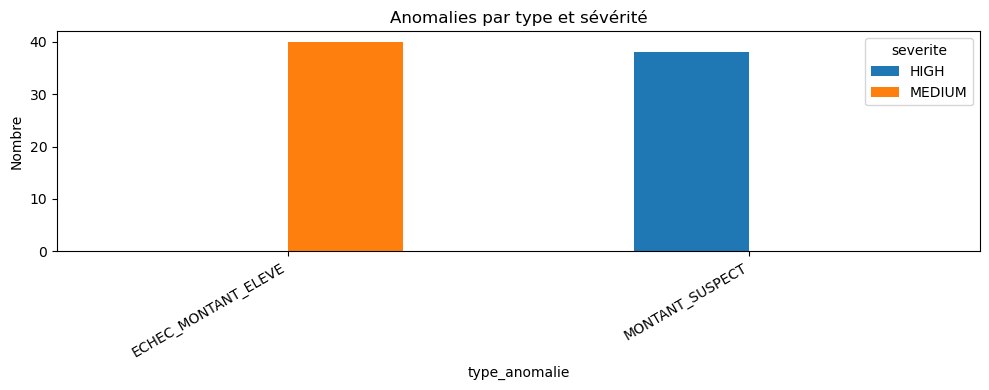

In [4]:
df_ano_type = pd.read_sql("""
    SELECT type_anomalie, severite, COUNT(*) AS nb
    FROM anomalies
    GROUP BY type_anomalie, severite
    ORDER BY nb DESC
""", conn)

print('=== ANOMALIES PAR TYPE ET SEVERITE ===')
print(df_ano_type.to_string(index=False))

# Barplot
pivot = df_ano_type.pivot_table(index='type_anomalie', columns='severite', values='nb', fill_value=0)
pivot.plot(kind='bar', figsize=(10, 4), title='Anomalies par type et sévérité')
plt.ylabel('Nombre')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Évolution temporelle des transactions

/tmp/ipykernel_6015/2796486325.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_temps = pd.read_sql("""


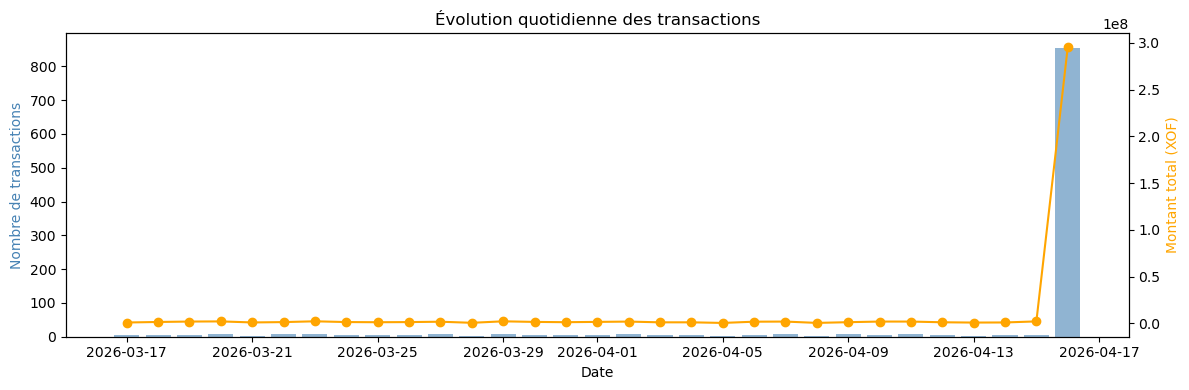

In [5]:
df_temps = pd.read_sql("""
    SELECT
        DATE(timestamp_transaction) AS date,
        COUNT(*) AS nb_transactions,
        ROUND(SUM(montant)::numeric, 0) AS montant_total
    FROM paiements
    WHERE statut = 'SUCCESS'
    GROUP BY DATE(timestamp_transaction)
    ORDER BY date
""", conn)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(df_temps['date'], df_temps['nb_transactions'], alpha=0.6, label='Nb transactions', color='steelblue')
ax2.plot(df_temps['date'], df_temps['montant_total'], color='orange', marker='o', label='Montant (XOF)')

ax1.set_xlabel('Date')
ax1.set_ylabel('Nombre de transactions', color='steelblue')
ax2.set_ylabel('Montant total (XOF)', color='orange')
plt.title('Évolution quotidienne des transactions')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

## 5. Taux de change XOF/USD (Source 3)

/tmp/ipykernel_6015/218661538.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_taux = pd.read_sql("""


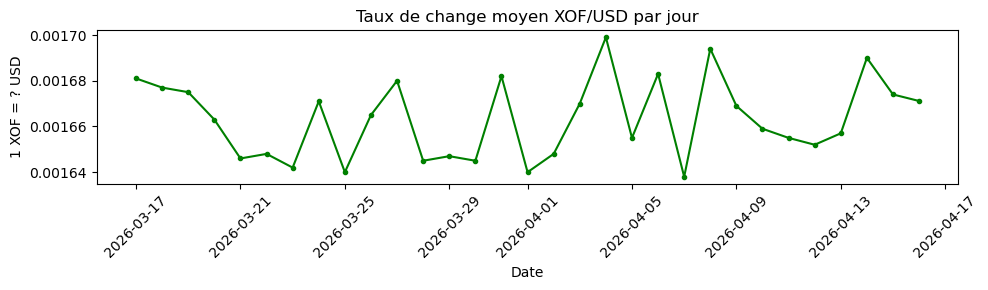

,date,taux_moyen
26,2026-04-12,0.001652
27,2026-04-13,0.001657
28,2026-04-14,0.001690
29,2026-04-15,0.001674
30,2026-04-16,0.001671


In [6]:
df_taux = pd.read_sql("""
    SELECT DATE(timestamp_collecte) AS date, AVG(taux) AS taux_moyen
    FROM taux_change
    GROUP BY DATE(timestamp_collecte)
    ORDER BY date
""", conn)

plt.figure(figsize=(10, 3))
plt.plot(df_taux['date'], df_taux['taux_moyen'], color='green', marker='.')
plt.title('Taux de change moyen XOF/USD par jour')
plt.ylabel('1 XOF = ? USD')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_taux.tail()

## 6. Catalogue produits enrichi (prix USD calculé par Airflow)

In [7]:
df_produits = pd.read_sql("""
    SELECT produit_id, nom, categorie, prix_xof, prix_usd, stock, fournisseur
    FROM produits
    ORDER BY categorie, prix_xof DESC
""", conn)

print(f'{len(df_produits)} produits dans le catalogue')

# Prix moyen par catégorie
df_cat = df_produits.groupby('categorie').agg(
    nb_produits=('produit_id', 'count'),
    prix_moyen_xof=('prix_xof', 'mean'),
    stock_total=('stock', 'sum')
).round(0).reset_index()

df_cat.sort_values('prix_moyen_xof', ascending=False)

20 produits dans le catalogue


/tmp/ipykernel_6015/1809382302.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_produits = pd.read_sql("""


,categorie,nb_produits,prix_moyen_xof,stock_total
2,Electronique,7,235000.0,305
4,Maison,2,155000.0,30
5,Mode,2,50000.0,120
1,Beaute,2,46750.0,130
6,Sport,2,28750.0,120
0,Alimentation,2,13000.0,350
7,Telephonie,1,5000.0,1000
3,Livres,2,4350.0,700


In [8]:
conn.close()
print('Analyse terminée.')

Analyse terminée.
